c:\Users\khiz2\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


[0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 0, 0, 2, 2, 2, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 

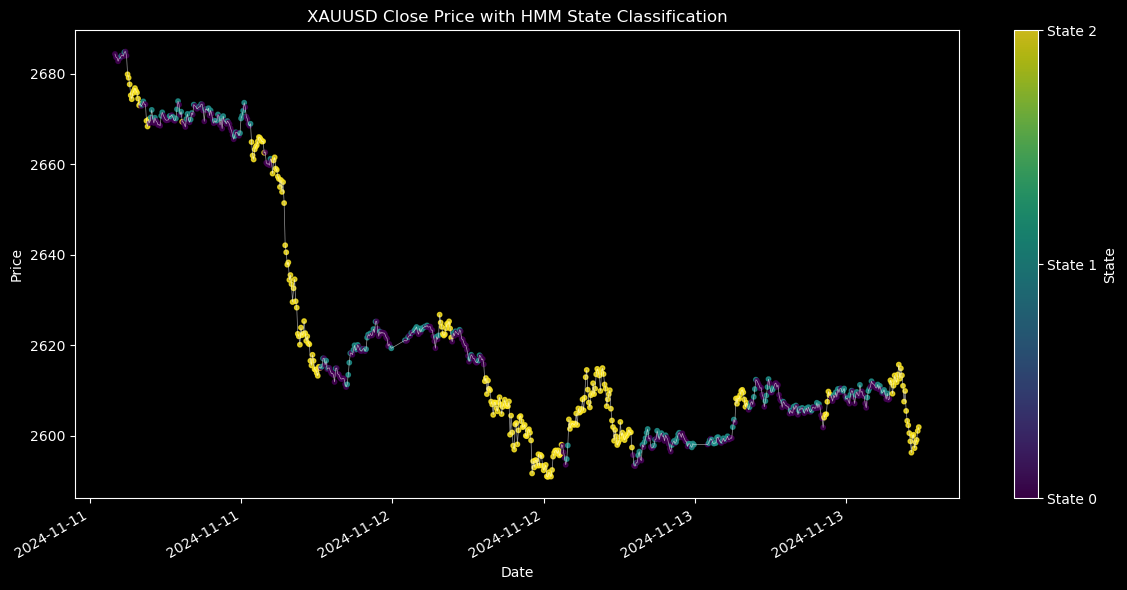

State 0:
  Mean: [-0.29561438 -0.57306708 -0.50424698]
  Covariance: [[ 0.18107046 -0.04830283 -0.13204169]
 [-0.04830283  0.18779867  0.06744165]
 [-0.13204169  0.06744165  0.22670407]]

State 1:
  Mean: [ 0.59163886 -0.59800733 -0.45564995]
  Covariance: [[0.27714479 0.10109098 0.2330329 ]
 [0.10109098 0.18910355 0.12552834]
 [0.2330329  0.12552834 0.28476916]]

State 2:
  Mean: [-0.11164285  1.0367865   0.86161456]
  Covariance: [[ 2.03064487 -0.08899604 -0.26714704]
 [-0.08899604  0.76342805  0.26786171]
 [-0.26714704  0.26786171  1.17233478]]



In [5]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from hmmlearn import hmm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
plt.style.use('dark_background')

# Step 1: Connect to MT5 and fetch data
if not mt5.initialize():
    print("MT5 initialization failed")
    quit()

# Set the timeframe and symbol
symbol = "XAUUSD"
timeframe = mt5.TIMEFRAME_M5

# Calculate the date range for the previous week
end_date = datetime.now()
start_date = end_date - timedelta(days=4)

# Fetch the data
rates = mt5.copy_rates_range(symbol, timeframe, start_date, end_date)
mt5.shutdown()

# Convert to DataFrame
df = pd.DataFrame(rates)
df['time'] = pd.to_datetime(df['time'], unit='s')
df.set_index('time', inplace=True)

# Step 2: Preprocess the data
df['returns'] = np.log(df['close'] / df['close'].shift(1))
df['volatility'] = df['returns'].rolling(window=12).std()
df['range'] = df['high'] - df['low']
df.dropna(inplace=True)

# Remove any remaining inf or NaN values
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Normalize the features
scaler = StandardScaler()
features = ['returns', 'volatility', 'range']
df[features] = scaler.fit_transform(df[features])

# Step 3: Implement the Hidden Markov Model
model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)

# Step 4: Train the model and predict states
X = df[features].values
model.fit(X)
hidden_states = model.predict(X)

print([state for state in hidden_states])

# Step 5: Plot the results
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the close price
ax.plot(df.index, df['close'], color='white', alpha=0.6, linewidth=0.5)

# Plot the hidden states as colored dots on the price chart
scatter = ax.scatter(df.index, df['close'], c=hidden_states, cmap='viridis', s=10, alpha=0.8)

ax.set_title('XAUUSD Close Price with HMM State Classification')
ax.set_ylabel('Price')
ax.set_xlabel('Date')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('State')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['State 0', 'State 1', 'State 2'])

# Format x-axis to show dates nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()  # Rotation

plt.tight_layout()
plt.show()

# Print state statistics
for i in range(model.n_components):
    print(f"State {i}:")
    print(f"  Mean: {model.means_[i]}")
    print(f"  Covariance: {model.covars_[i]}")
    print()